# Submission deep-dive (N episodes, one submission)

Purpose: is a symptom **structural or noise**? Exports a noise-floor dict for `submission_comparison.ipynb`.

**Run all cells** — downloads Kaggle replays and builds the summary JSON automatically when needed (cached under `kaggle_logs/`).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "agent").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "experiments"))

import submission_nb as snb
from agent.pricing import MARKET_PARAMS

SUBMISSION_ID = "55938405"  # TwoLand example; change as needed
US_NAME = "Your Name"  # Kaggle team name (matches info.TeamNames)
REFRESH = False  # True → re-summarize even if JSON exists
DAYS = list(range(snb.SEASON_DAYS))

In [2]:
summary = snb.ensure_summary(
    SUBMISSION_ID, US_NAME, ROOT, refresh=REFRESH, verbose=True
)
games = summary.get("games") or []
agg = summary.get("aggregate") or {}

print(f"submission={summary.get('submission_id')}  n={summary.get('n_episodes')}")
print(f"us_name={summary.get('us_name')}  seat_counts={agg.get('seat_counts')}")
print(f"win_rate={agg.get('win_rate', 0):.3f}")

rows = [snb.episode_row(g) for g in games]
df_ep = pd.DataFrame(rows)
df_ep.head()

Using cached summary /media/wlaki/W/DS_projects/Kaggle/kaggriculture/kaggle_logs/55938405/55938405.json
submission=55938405  n=41
us_name=Milos Vlainic  seat_counts={'0': 20, '1': 21}
win_rate=0.512


,episode_id,seed,reward_us,reward_opp,win,noop_ops,move_overhead,ripe_mean_latency,unexplained_delta,tile_day_utilization,idle_empty,idle_weed,total_hire_spend,days_below_floor,n_steps
0,104537942,0,93265.0,86095.0,True,3,0.776153,49.178707,1251.0,0.695246,7427,1262,1830,0,720
1,104538518,1913562515,55992.0,49320.0,True,2,0.759459,49.049505,910.0,0.710525,6856,1374,1775,0,720
2,104538926,1976862857,52352.0,60892.0,False,4,0.744357,46.837736,3625.0,0.717125,6172,1423,1587,0,720
3,104539378,232646491,67793.0,44663.0,True,6,0.846893,42.917391,745.0,0.591138,10627,742,1090,0,720
4,104539820,890360810,60861.0,62411.0,False,9,0.787837,40.324723,3460.0,0.702437,7008,1427,1707,0,720


## 1. Score distribution + noise floor

mean=71423  median=71694  std=13183
win_rate=0.512


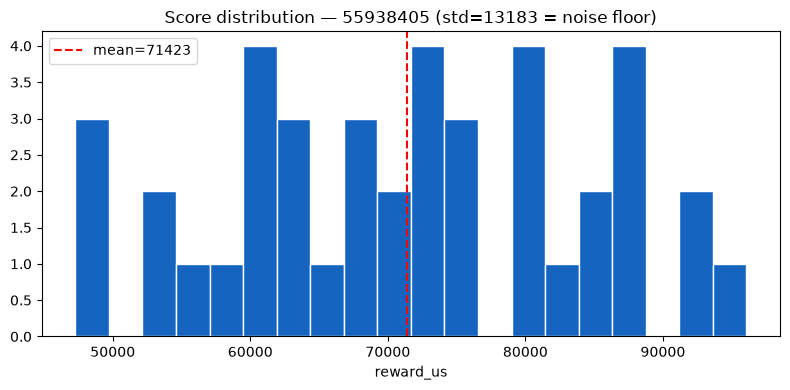

reward_us               13182.630
move_overhead               0.032
noop_ops                    3.486
ripe_mean_latency           5.123
unexplained_delta        1098.545
tile_day_utilization        0.039
total_hire_spend          303.340
days_below_floor            0.000
score_std               13182.630
Name: std_across_episodes, dtype: float64

In [3]:
rewards = df_ep["reward_us"].dropna().astype(float)
score_std = float(rewards.std()) if len(rewards) > 1 else 0.0
noise_floor = snb.noise_floor_from_games(games)
noise_floor["score_std"] = score_std

print(f"mean={rewards.mean():.0f}  median={rewards.median():.0f}  std={score_std:.0f}")
print(f"win_rate={df_ep['win'].mean():.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(rewards, bins=min(20, max(5, len(rewards) // 2)), color="#1565c0", edgecolor="white")
ax.axvline(rewards.mean(), color="red", ls="--", label=f"mean={rewards.mean():.0f}")
ax.set_xlabel("reward_us")
ax.set_title(f"Score distribution — {SUBMISSION_ID} (std={score_std:.0f} = noise floor)")
ax.legend()
plt.tight_layout()
plt.show()

pd.Series(noise_floor, name="std_across_episodes").round(3)

## 2. Day-banded series (mean ± std)

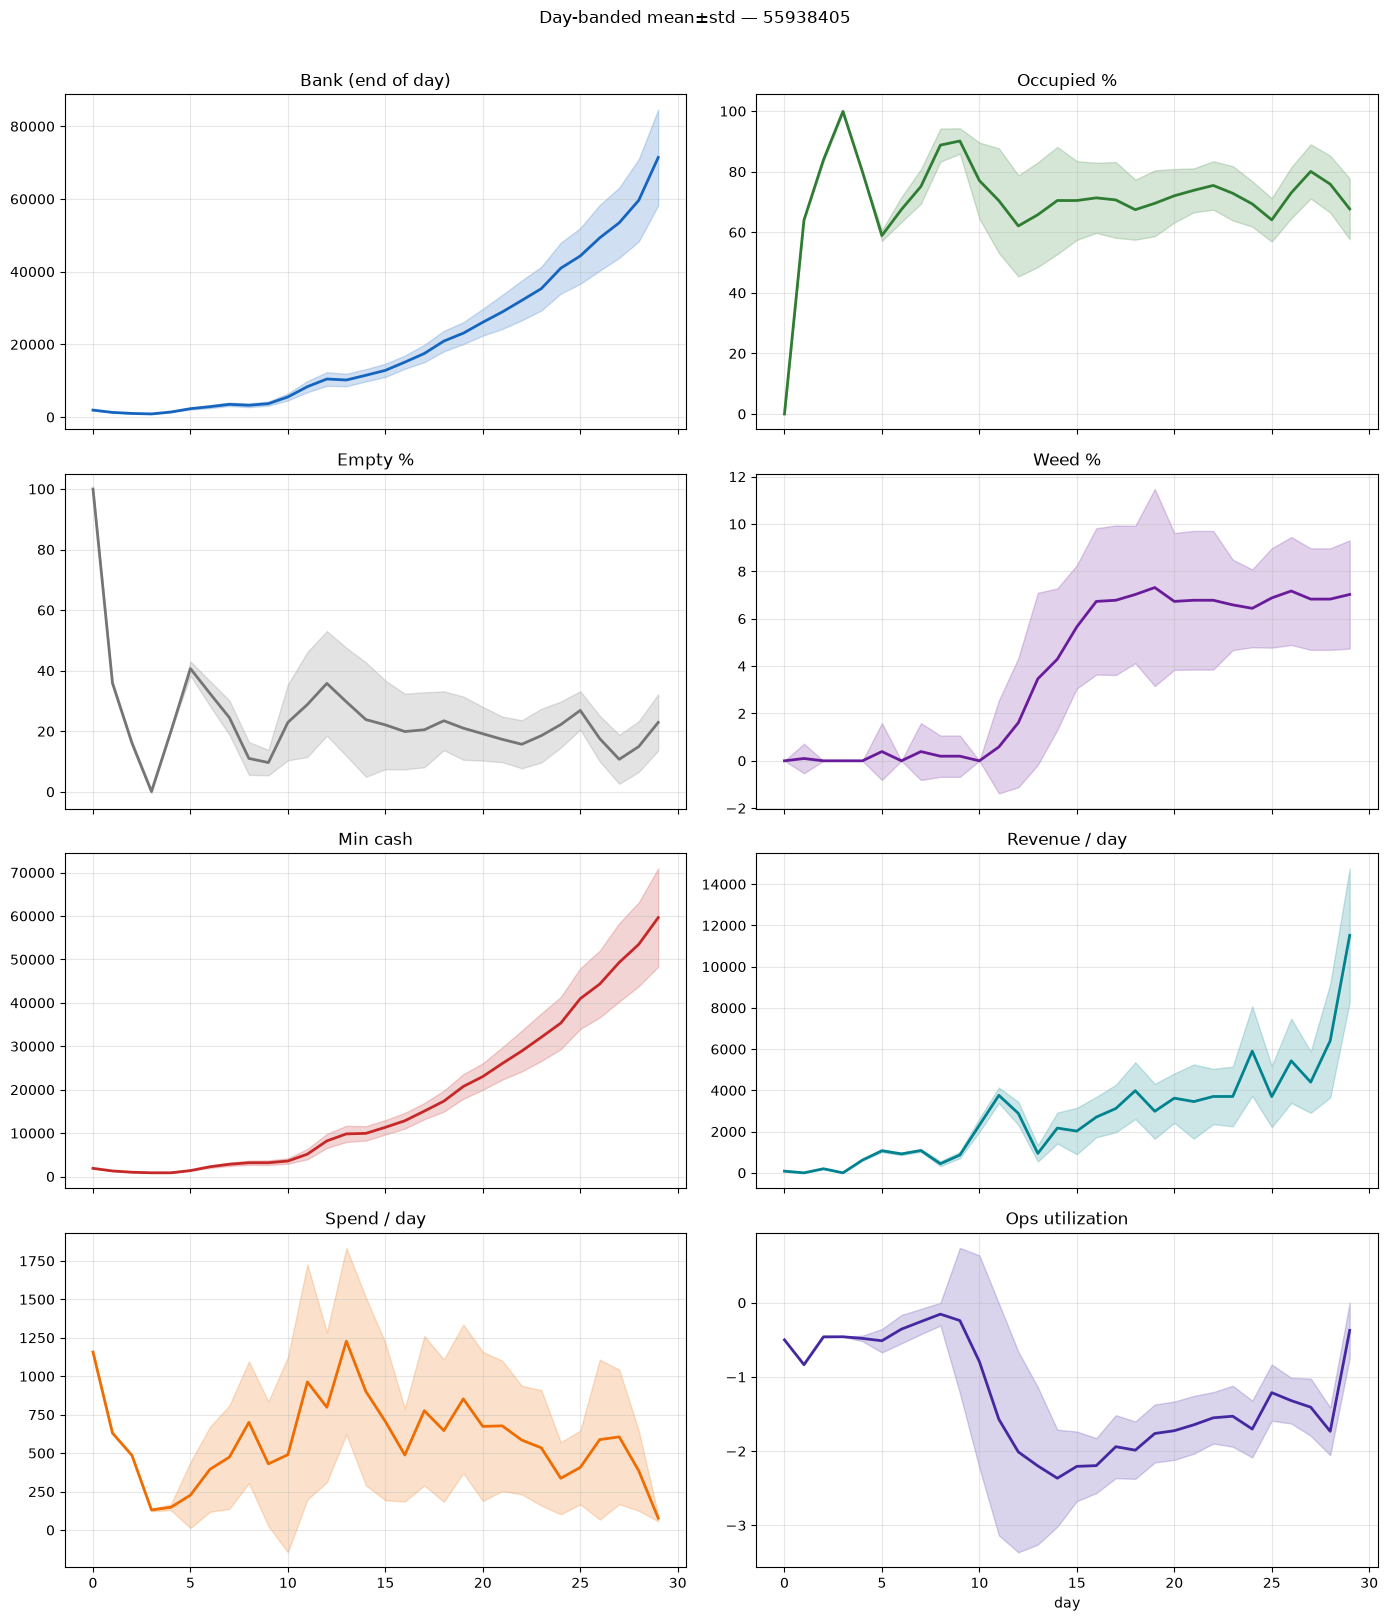

In [4]:
series_specs = [
    ("Bank (end of day)", snb.bank_end_series, "#1565c0"),
    ("Occupied %", snb.occupied_pct_series, "#2e7d32"),
    ("Empty %", lambda g: snb.tile_pct_series(g, "empty"), "#757575"),
    ("Weed %", lambda g: snb.tile_pct_series(g, "weed"), "#6a1b9a"),
    ("Min cash", snb.min_cash_series, "#c62828"),
    ("Revenue / day", snb.revenue_series, "#00838f"),
    ("Spend / day", snb.spend_series, "#ef6c00"),
    ("Ops utilization", snb.ops_util_series, "#4527a0"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.ravel()
for ax, (title, fn, color) in zip(axes, series_specs):
    mean, std = snb.day_band(games, fn)
    m = np.array(mean, dtype=float)
    s = np.array(std, dtype=float)
    ax.plot(DAYS, m, color=color, lw=2)
    ax.fill_between(DAYS, m - s, m + s, color=color, alpha=0.2)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("day")
fig.suptitle(f"Day-banded mean±std — {SUBMISSION_ID}", y=1.01)
plt.tight_layout()
plt.show()

## 3. KPI boxplots across episodes

/tmp/ipykernel_585198/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_585198/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_585198/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)
/tmp/ipykernel_585198/2557771920.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(vals.dropna(), vert=True)


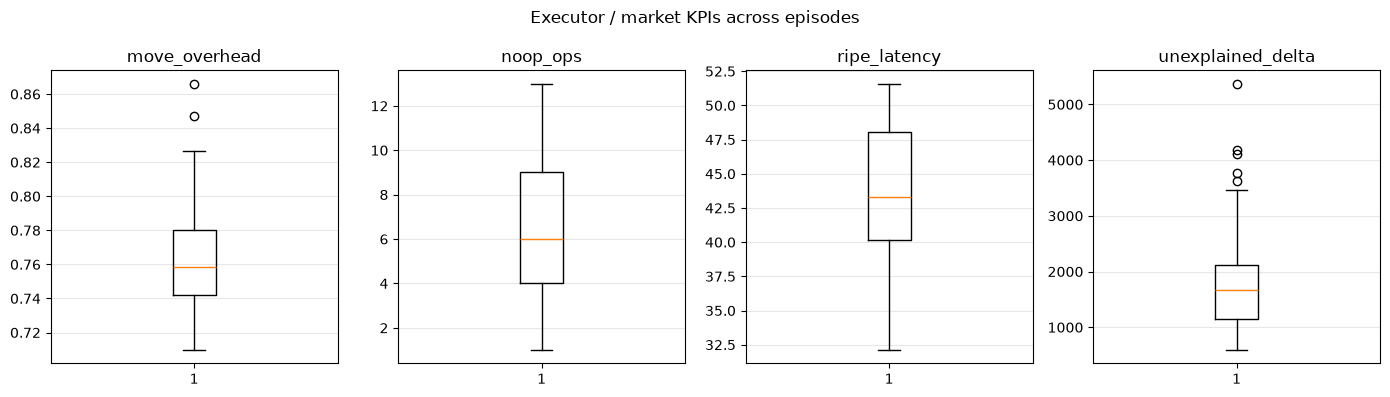

In [5]:
scalar_kpis = [
    ("move_overhead", df_ep["move_overhead"]),
    ("noop_ops", df_ep["noop_ops"]),
    ("ripe_latency", df_ep["ripe_mean_latency"]),
    ("unexplained_delta", df_ep["unexplained_delta"]),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (label, vals) in zip(axes, scalar_kpis):
    ax.boxplot(vals.dropna(), vert=True)
    ax.set_title(label)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Executor / market KPIs across episodes")
plt.tight_layout()
plt.show()

/tmp/ipykernel_585198/22540819.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)
/tmp/ipykernel_585198/22540819.py:28: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)


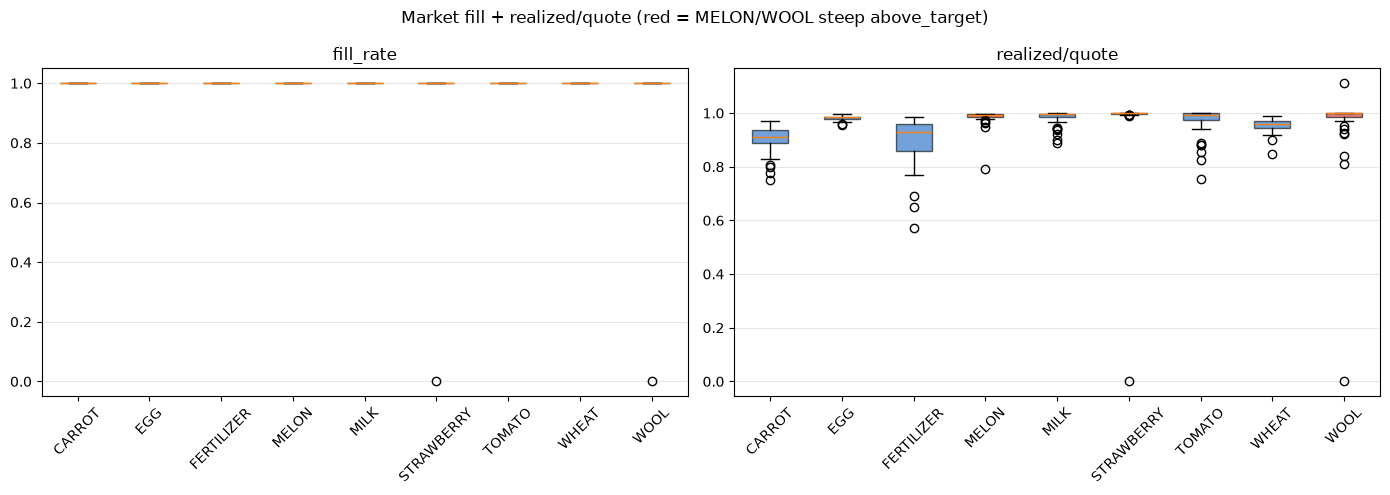

fill_rate           realized_vs_quote          
             mean       std              mean       std
product                                                
MELON     1.00000  0.000000          0.984319  0.032654
WOOL      0.97561  0.156174          0.959784  0.160244

In [6]:
# Fill rate + realized/quote per product (MELON & WOOL highlighted)
products = sorted({p for g in games for p in (snb.us_kpi(g)[1].get("fill_rate") or {})})
fill_rows = []
for g in games:
    eid = g.get("episode_id")
    for prod in products:
        fill_rows.append({
            "episode_id": eid,
            "product": prod,
            "fill_rate": snb.fill_rate_for(g, prod),
            "realized_vs_quote": snb.realized_quote_for(g, prod),
            "steep_glut": prod in snb.STEEP_GLUT_PRODUCTS,
            "above_target": getattr(MARKET_PARAMS.get(prod), "above_target", None),
        })
df_fill = pd.DataFrame(fill_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylab in zip(axes, ["fill_rate", "realized_vs_quote"], ["fill_rate", "realized/quote"]):
    data = []
    labels = []
    colors = []
    for prod in products:
        sub = df_fill[df_fill["product"] == prod][col].dropna()
        if len(sub):
            data.append(sub.values)
            labels.append(prod)
            colors.append("#c62828" if prod in snb.STEEP_GLUT_PRODUCTS else "#1565c0")
    bp = ax.boxplot(data, tick_labels=labels, vert=True, patch_artist=True)
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.6)
    ax.set_title(ylab)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", alpha=0.3)
fig.suptitle("Market fill + realized/quote (red = MELON/WOOL steep above_target)")
plt.tight_layout()
plt.show()

df_fill[df_fill["steep_glut"]].groupby("product")[["fill_rate", "realized_vs_quote"]].agg(["mean", "std"])

## 4. Land-purchase timing

In [7]:
land_rows = []
for g in games:
    land_rows.extend(snb.land_purchase_rows(g))
df_land = pd.DataFrame(land_rows)
if df_land.empty:
    print("No land_events in this submission.")
else:
    display(df_land.sort_values(["day", "episode_id"]))

,episode_id,seed,day,quadrant,cost,cash_before,cash_after,days_below_floor
4,104539820,890360810,9,NE,1000,3598.0,2894.0,0
20,104558460,1028404917,9,NE,1000,3807.0,3303.0,0
30,104680094,1594863131,9,NE,1000,2879.0,1893.0,0
0,104537942,0,10,NE,1000,3424.0,4715.0,0
1,104538518,1913562515,10,NE,1000,3910.0,4066.0,0
6,104540718,1497463817,10,NE,1000,4406.0,4008.0,0
15,104544693,981690784,10,NE,1000,4236.0,4569.0,0
22,104573546,715904783,10,NE,1000,4212.0,5136.0,0
32,104719196,1576333467,10,NE,1000,3850.0,5014.0,0
39,104846026,1913952498,10,NE,1000,4083.0,4328.0,0


## 5. Anomaly table

In [8]:
df_anom = pd.DataFrame(snb.anomaly_rows(games))
if df_anom.empty:
    print("No anomalies flagged.")
else:
    display(df_anom)

NOISE_FLOOR = noise_floor
print(f"\nNOISE_FLOOR ready (score_std={NOISE_FLOOR.get('score_std', 0):.0f})")

,episode_id,seed,reward_us,reasons
0,104558460,1028404917,53044.0,|unexplained_delta|>5199



NOISE_FLOOR ready (score_std=13183)
